# Projet Deep Learning – Partie III : RNN, LSTM, GRU et Seq2Seq

**Tâche :** Traduction automatique Français → Anglais (corpus Tatoeba simplifié)  


In [1]:
# ── CELLULE 1 – Imports ─────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import collections
import random
import math

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__)
print('Device  :', device)

PyTorch : 2.11.0+cpu
Device  : cpu


---
## 1. Modèles de langage : objectif probabiliste et perplexité

### Objectif probabiliste
Un modèle de langage attribue une probabilité à une séquence de tokens :
$$P(x_1, x_2, \ldots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, \ldots, x_{t-1})$$

L'idée : **prédire le prochain token à partir du contexte passé**.

### Perplexité
La perplexité mesure l'incertitude moyenne du modèle sur chaque token :
$$\text{PPL} = \exp\left(-\frac{1}{T} \sum_{t=1}^{T} \log P(x_t \mid x_{<t})\right)$$

- PPL basse → le modèle prédit bien
- PPL = 1 → prédiction parfaite
- PPL = |V| → le modèle ne sait rien (distribution uniforme sur le vocabulaire)

### Approches n-grammes vs RNN
| Critère | N-grammes | RNN |
|---|---|---|
| Contexte | Fenêtre fixe (n-1 tokens) | Mémoire illimitée (en théorie) |
| Généralisation | Faible (sparsité) | Bonne (embedding) |
| Coût | Faible | Plus élevé |

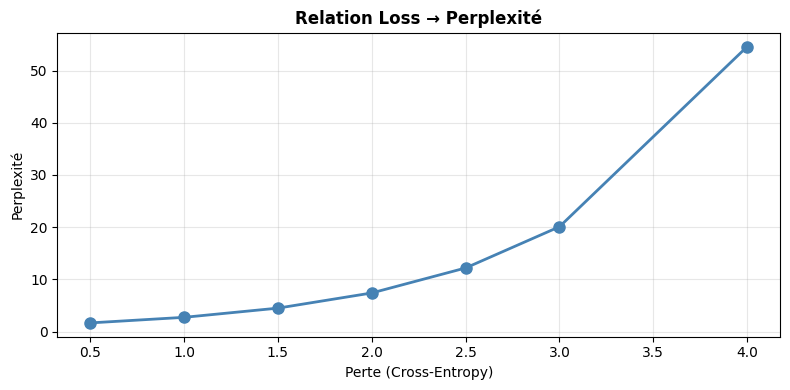

  Loss        PPL
------------------
   0.5       1.65
   1.0       2.72
   1.5       4.48
   2.0       7.39
   2.5      12.18
   3.0      20.09
   4.0      54.60


In [2]:
# ── CELLULE 2 – Illustration de la perplexité ────────────────────────────────
def perplexity(loss):
    """Calcule la perplexité à partir de la perte cross-entropique moyenne."""
    return math.exp(loss)

losses = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
ppls   = [perplexity(l) for l in losses]

plt.figure(figsize=(8, 4))
plt.plot(losses, ppls, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Perte (Cross-Entropy)')
plt.ylabel('Perplexité')
plt.title('Relation Loss → Perplexité', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('perplexite.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Loss':>6} {'PPL':>10}")
print('-' * 18)
for l, p in zip(losses, ppls):
    print(f"{l:>6.1f} {p:>10.2f}")

---
## 2. Préparation des données

In [3]:
# ── CELLULE 3 – Corpus fra-eng ───────────────────────────────────────────────
# Corpus parallèle simplifié inspiré de Tatoeba
pairs = [
    ('je suis etudiant',          'i am a student'),
    ('il fait beau',              'the weather is nice'),
    ('bonjour monde',             'hello world'),
    ('je mange une pomme',        'i eat an apple'),
    ('elle est belle',            'she is beautiful'),
    ('nous aimons python',        'we love python'),
    ('le chat dort',              'the cat sleeps'),
    ('je suis fatigue',           'i am tired'),
    ('bonne nuit',                'good night'),
    ('merci beaucoup',            'thank you very much'),
    ('je parle francais',         'i speak french'),
    ('il aime le sport',          'he likes sport'),
    ('nous sommes heureux',       'we are happy'),
    ('elle mange du pain',        'she eats bread'),
    ('bonjour comment vas tu',    'hello how are you'),
    ('je lis un livre',           'i read a book'),
    ('il fait froid',             'it is cold'),
    ('elle chante bien',          'she sings well'),
    ('nous travaillons dur',      'we work hard'),
    ('le chien court vite',       'the dog runs fast'),
]

print(f'Corpus : {len(pairs)} paires de phrases')
print('Exemples :')
for fr, en in pairs[:3]:
    print(f'  FR: {fr:<30} EN: {en}')

Corpus : 20 paires de phrases
Exemples :
  FR: je suis etudiant               EN: i am a student
  FR: il fait beau                   EN: the weather is nice
  FR: bonjour monde                  EN: hello world


In [4]:
# ── CELLULE 4 – Tokenisation et construction du vocabulaire ─────────────────
# Tokens spéciaux
PAD, BOS, EOS, UNK = '<pad>', '<bos>', '<eos>', '<unk>'
SPECIAL = [PAD, BOS, EOS, UNK]

def build_vocab(sentences):
    """
    Construit un vocabulaire {token → id} à partir d'une liste de phrases.
    Les tokens spéciaux sont toujours en tête.
    """
    counter = collections.Counter()
    for s in sentences:
        counter.update(s.split())
    vocab = {t: i for i, t in enumerate(SPECIAL)}
    for word, _ in counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)
    inv_vocab = {i: t for t, i in vocab.items()}
    return vocab, inv_vocab

src_sents = [p[0] for p in pairs]
tgt_sents = [p[1] for p in pairs]

src_vocab, src_inv = build_vocab(src_sents)
tgt_vocab, tgt_inv = build_vocab(tgt_sents)

print(f'Vocabulaire source : {len(src_vocab)} tokens')
print(f'Vocabulaire cible  : {len(tgt_vocab)} tokens')
print(f'\nTokens spéciaux : PAD={src_vocab[PAD]} | BOS={src_vocab[BOS]} | EOS={src_vocab[EOS]} | UNK={src_vocab[UNK]}')
print(f'\nExtrait vocab source : {list(src_vocab.items())[:8]}')

Vocabulaire source : 51 tokens
Vocabulaire cible  : 52 tokens

Tokens spéciaux : PAD=0 | BOS=1 | EOS=2 | UNK=3

Extrait vocab source : [('<pad>', 0), ('<bos>', 1), ('<eos>', 2), ('<unk>', 3), ('je', 4), ('il', 5), ('elle', 6), ('nous', 7)]


In [5]:
# ── CELLULE 5 – Encodage, padding et masquage ────────────────────────────────
NUM_STEPS = 12   # longueur maximale des séquences

def truncate_pad(tokens, num_steps, pad_id):
    """Tronque ou complète une séquence à num_steps."""
    if len(tokens) > num_steps:
        return tokens[:num_steps]
    return tokens + [pad_id] * (num_steps - len(tokens))

def encode(sentence, vocab, num_steps):
    """Encode une phrase : BOS + tokens + EOS + padding."""
    ids = [vocab.get(w, vocab[UNK]) for w in sentence.split()]
    ids = [vocab[BOS]] + ids + [vocab[EOS]]
    return truncate_pad(ids, num_steps, vocab[PAD])

# Encodage de tout le corpus
src_enc = [encode(s, src_vocab, NUM_STEPS) for s in src_sents]
tgt_enc = [encode(s, tgt_vocab, NUM_STEPS) for s in tgt_sents]

src_t = torch.tensor(src_enc, dtype=torch.long)
tgt_t = torch.tensor(tgt_enc, dtype=torch.long)

print(f'Tenseur source : {src_t.shape}  (nb_phrases, num_steps)')
print(f'Tenseur cible  : {tgt_t.shape}')
print(f'\nExemple :')
print(f'  FR  : "{src_sents[0]}"')
print(f'  IDs : {src_enc[0]}')
print(f'  Décodé : {[src_inv[i] for i in src_enc[0]]}')

dataset     = TensorDataset(src_t, tgt_t)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
print(f'\nDataLoader créé : {len(train_loader)} batches de 4')

Tenseur source : torch.Size([20, 12])  (nb_phrases, num_steps)
Tenseur cible  : torch.Size([20, 12])

Exemple :
  FR  : "je suis etudiant"
  IDs : [1, 4, 9, 13, 2, 0, 0, 0, 0, 0, 0, 0]
  Décodé : ['<bos>', 'je', 'suis', 'etudiant', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

DataLoader créé : 5 batches de 4


---
## 3. RNN simple

$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$
$$\hat{y}_t = \text{softmax}(W_{hq} h_t + b_q)$$

L'état caché $h_t$ est la **mémoire** du RNN : il résume ce qui a été observé jusqu'au temps $t$.

In [6]:
# ── CELLULE 6 – RNN simple ───────────────────────────────────────────────────
class RNNModel(nn.Module):
    """
    Modèle de langage RNN simple.
    Embedding → RNN → Linear(vocab)
    """
    def __init__(self, vocab_size, embed_dim=32, hidden=64, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn   = nn.RNN(embed_dim, hidden, num_layers=num_layers,
                            batch_first=True)
        self.fc    = nn.Linear(hidden, vocab_size)

    def forward(self, x, h=None):
        emb = self.embed(x)           # (B, T, embed_dim)
        out, h = self.rnn(emb, h)     # out: (B, T, hidden)
        return self.fc(out), h        # logits: (B, T, vocab_size)

# Vérification des dimensions
rnn_model = RNNModel(len(src_vocab))
x_demo    = torch.randint(0, len(src_vocab), (4, NUM_STEPS))
out, h    = rnn_model(x_demo)
print(f'RNN  entrée : {x_demo.shape}')
print(f'RNN  sortie : {out.shape}   (B, T, vocab_size)')
print(f'RNN  hidden : {h.shape}     (num_layers, B, hidden)')
print(f'Paramètres  : {sum(p.numel() for p in rnn_model.parameters()):,}')

RNN  entrée : torch.Size([4, 12])
RNN  sortie : torch.Size([4, 12, 51])   (B, T, vocab_size)
RNN  hidden : torch.Size([1, 4, 64])     (num_layers, B, hidden)
Paramètres  : 11,219


---
## 4. LSTM – Long Short-Term Memory

Le LSTM résout le problème de gradient évanescent en introduisant une **cellule mémoire** $c_t$ et trois portes :

$$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f) \quad \text{(porte d'oubli)}$$
$$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i) \quad \text{(porte d'entrée)}$$
$$\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c) \quad \text{(candidat)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o) \quad \text{(porte de sortie)}$$
$$h_t = o_t \odot \tanh(c_t)$$

In [7]:
# ── CELLULE 7 – LSTM ─────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    """
    Modèle de langage LSTM.
    Différence vs RNN : état double (h_t, c_t) — h=hidden, c=cellule mémoire.
    """
    def __init__(self, vocab_size, embed_dim=32, hidden=64, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm  = nn.LSTM(embed_dim, hidden, num_layers=num_layers,
                             batch_first=True)
        self.fc    = nn.Linear(hidden, vocab_size)

    def forward(self, x, state=None):
        emb = self.embed(x)
        out, (h, c) = self.lstm(emb, state)   # état = (h, c)
        return self.fc(out), (h, c)

lstm_model = LSTMModel(len(src_vocab))
out, (h, c) = lstm_model(x_demo)
print(f'LSTM sortie  : {out.shape}')
print(f'LSTM hidden  : {h.shape}')
print(f'LSTM cell    : {c.shape}')
print(f'Paramètres   : {sum(p.numel() for p in lstm_model.parameters()):,}')

LSTM sortie  : torch.Size([4, 12, 51])
LSTM hidden  : torch.Size([1, 4, 64])
LSTM cell    : torch.Size([1, 4, 64])
Paramètres   : 30,035


---
## 5. GRU – Gated Recurrent Unit

Le GRU simplifie le LSTM : **pas de cellule séparée**, seulement deux portes :

$$z_t = \sigma(W_z x_t + U_z h_{t-1}) \quad \text{(mise à jour)}$$
$$r_t = \sigma(W_r x_t + U_r h_{t-1}) \quad \text{(réinitialisation)}$$
$$\tilde{h}_t = \tanh(W_h x_t + U_h(r_t \odot h_{t-1}))$$
$$h_t = z_t \odot h_{t-1} + (1 - z_t) \odot \tilde{h}_t$$

In [8]:
# ── CELLULE 8 – GRU ──────────────────────────────────────────────────────────
class GRUModel(nn.Module):
    """
    Modèle de langage GRU.
    Plus léger que LSTM : un seul état h_t (pas de cellule c_t).
    """
    def __init__(self, vocab_size, embed_dim=32, hidden=64, num_layers=1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru   = nn.GRU(embed_dim, hidden, num_layers=num_layers,
                            batch_first=True)
        self.fc    = nn.Linear(hidden, vocab_size)

    def forward(self, x, h=None):
        emb = self.embed(x)
        out, h = self.gru(emb, h)
        return self.fc(out), h

gru_model = GRUModel(len(src_vocab))
out, h    = gru_model(x_demo)
print(f'GRU sortie   : {out.shape}')
print(f'GRU hidden   : {h.shape}')
print(f'Paramètres   : {sum(p.numel() for p in gru_model.parameters()):,}')

# Tableau récapitulatif
print('\n=== Comparaison architecturale ===')
print(f"{'Modèle':<8} {'Portes':>8} {'États':>12} {'Paramètres':>12}")
print('-' * 44)
for name, m in [('RNN', rnn_model), ('LSTM', lstm_model), ('GRU', gru_model)]:
    n = sum(p.numel() for p in m.parameters())
    etats  = '(h)'     if name in ['RNN','GRU'] else '(h, c)'
    portes = '0'       if name == 'RNN' else ('3' if name=='LSTM' else '2')
    print(f"{name:<8} {portes:>8} {etats:>12} {n:>12,}")

GRU sortie   : torch.Size([4, 12, 51])
GRU hidden   : torch.Size([1, 4, 64])
Paramètres   : 23,763

=== Comparaison architecturale ===
Modèle     Portes        États   Paramètres
--------------------------------------------
RNN             0          (h)       11,219
LSTM            3       (h, c)       30,035
GRU             2          (h)       23,763


---
## 6. BPTT et gradient clipping

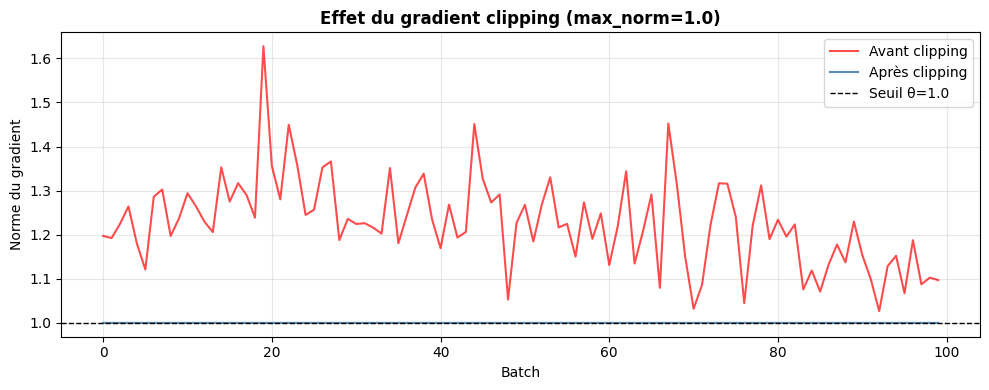

Observation : le clipping empêche les gradients explosifs de dépasser le seuil θ.


In [9]:
# ── CELLULE 9 – Illustration BPTT et gradient clipping ──────────────────────
# Entraînement d'un RNN simple avec suivi des normes de gradients

model_bptt = RNNModel(len(src_vocab))
opt        = torch.optim.SGD(model_bptt.parameters(), lr=0.1)
crit       = nn.CrossEntropyLoss(ignore_index=0)

grad_norms_avant = []
grad_norms_apres = []

for ep in range(20):
    for xb, _ in train_loader:
        opt.zero_grad()
        out, _ = model_bptt(xb[:, :-1])
        loss   = crit(out.reshape(-1, out.shape[-1]), xb[:, 1:].reshape(-1))
        loss.backward()

        # Norme du gradient AVANT clipping
        total_norm = 0
        for p in model_bptt.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        grad_norms_avant.append(total_norm ** 0.5)

        # Gradient clipping : si ||g|| > θ, renormaliser
        torch.nn.utils.clip_grad_norm_(model_bptt.parameters(), max_norm=1.0)

        # Norme APRÈS clipping
        total_norm = 0
        for p in model_bptt.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        grad_norms_apres.append(total_norm ** 0.5)

        opt.step()

plt.figure(figsize=(10, 4))
plt.plot(grad_norms_avant, label='Avant clipping', color='red',      alpha=0.7, linewidth=1.5)
plt.plot(grad_norms_apres, label='Après clipping', color='steelblue',alpha=0.9, linewidth=1.5)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Seuil θ=1.0')
plt.xlabel('Batch'); plt.ylabel('Norme du gradient')
plt.title('Effet du gradient clipping (max_norm=1.0)', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gradient_clipping.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation : le clipping empêche les gradients explosifs de dépasser le seuil θ.')

---
## 7. Comparaison RNN / LSTM / GRU

In [10]:
# ── CELLULE 10 – Entraînement comparatif RNN / LSTM / GRU ───────────────────
def train_lm(model, loader, epochs=40, lr=5e-3):
    """
    Entraîne un modèle de langage (prédiction du prochain token).
    Entrée  : x[:, :-1]   (tous tokens sauf le dernier)
    Cible   : x[:, 1:]    (tous tokens sauf le premier)
    """
    model.to(device)
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(ignore_index=0)
    hist = []
    for ep in range(epochs):
        model.train()
        total = 0
        for xb, _ in loader:
            xb = xb.to(device)
            opt.zero_grad()
            out, _ = model(xb[:, :-1])   # entrée : tokens 0..T-2
            loss   = crit(
                out.reshape(-1, out.shape[-1]),
                xb[:, 1:].reshape(-1)     # cible  : tokens 1..T-1
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item()
        hist.append(total / len(loader))
    return hist

print('Entraînement RNN / LSTM / GRU (40 epochs)...')
hists = {}
for name, ModelClass in [('RNN', RNNModel), ('LSTM', LSTMModel), ('GRU', GRUModel)]:
    m    = ModelClass(len(src_vocab))
    hist = train_lm(m, train_loader, epochs=40)
    hists[name] = hist
    print(f'  {name:<6} | loss finale = {hist[-1]:.4f} | PPL = {perplexity(hist[-1]):.2f}')

Entraînement RNN / LSTM / GRU (40 epochs)...
  RNN    | loss finale = 0.7667 | PPL = 2.15
  LSTM   | loss finale = 0.7676 | PPL = 2.15
  GRU    | loss finale = 0.7607 | PPL = 2.14


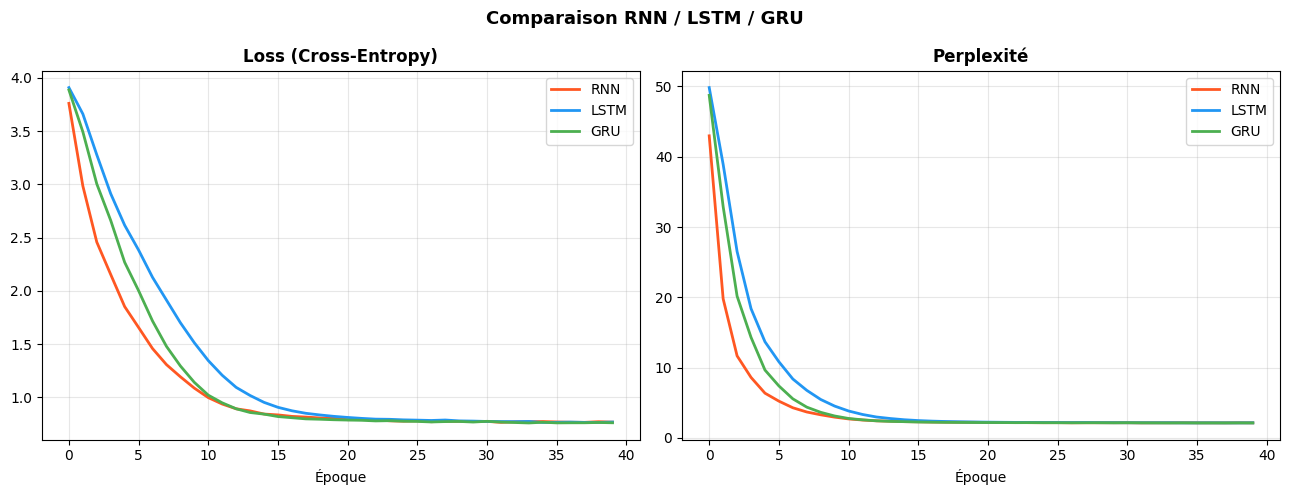

In [11]:
# ── CELLULE 11 – Courbes de convergence ─────────────────────────────────────
colors = {'RNN':'#FF5722', 'LSTM':'#2196F3', 'GRU':'#4CAF50'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, hist in hists.items():
    ppls = [perplexity(l) for l in hist]
    axes[0].plot(hist, color=colors[name], linewidth=2, label=name)
    axes[1].plot(ppls, color=colors[name], linewidth=2, label=name)

axes[0].set_title('Loss (Cross-Entropy)',  fontweight='bold')
axes[1].set_title('Perplexité',            fontweight='bold')
for ax in axes:
    ax.set_xlabel('Époque')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison RNN / LSTM / GRU', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_rnn.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Architecture Encodeur–Décodeur Seq2Seq

L'architecture Seq2Seq sépare le traitement en deux modules :

$$\underbrace{\text{Encodeur}(x_{1:T_x})}_{\text{contexte } c} \rightarrow \underbrace{\text{Décodeur}(y_{<t}, c)}_{\hat{y}_t}$$

- **Encodeur** : lit la phrase source et produit un vecteur de contexte
- **Décodeur** : génère la traduction token par token, conditionné sur le contexte
- **Teacher forcing** : pendant l'entraînement, on donne le vrai token précédent au décodeur (et non sa prédiction)

In [12]:
# ── CELLULE 12 – Encodeur GRU ────────────────────────────────────────────────
class Encoder(nn.Module):
    """
    Encodeur GRU : lit la séquence source et produit
    - enc_outputs : toutes les sorties cachées (B, T, hidden)
    - hidden      : dernier état caché (num_layers, B, hidden)
    """
    def __init__(self, src_vocab_size, embed_dim=32, hidden=64,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(src_vocab_size, embed_dim, padding_idx=0)
        self.gru   = nn.GRU(embed_dim, hidden, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)

    def forward(self, src):
        emb = self.embed(src)                 # (B, T, embed_dim)
        enc_outputs, hidden = self.gru(emb)   # outputs: (B,T,hidden) | hidden: (L,B,H)
        return enc_outputs, hidden

enc_test = Encoder(len(src_vocab))
src_b    = src_t[:4]
enc_out, enc_h = enc_test(src_b)
print(f'Encodeur outputs : {enc_out.shape}   (B, T, hidden)')
print(f'Encodeur hidden  : {enc_h.shape}     (num_layers, B, hidden)')

Encodeur outputs : torch.Size([4, 12, 64])   (B, T, hidden)
Encodeur hidden  : torch.Size([2, 4, 64])     (num_layers, B, hidden)


In [13]:
# ── CELLULE 13 – Décodeur GRU ────────────────────────────────────────────────
class Decoder(nn.Module):
    """
    Décodeur conditionnel GRU.
    À chaque pas, reçoit :
      - le token précédent y_{t-1}
      - l'état caché précédent h_{t-1}
      - le contexte c (dernier état de l'encodeur)
    Concatène embedding(y_{t-1}) et contexte avant de passer dans le GRU.
    """
    def __init__(self, tgt_vocab_size, embed_dim=32, hidden=64,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=0)
        # entrée GRU = embedding + contexte
        self.gru   = nn.GRU(embed_dim + hidden, hidden, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc    = nn.Linear(hidden, tgt_vocab_size)

    def forward(self, tgt_token, hidden, context):
        emb = self.embed(tgt_token.unsqueeze(1))   # (B, 1, embed_dim)
        ctx = context.unsqueeze(1)                  # (B, 1, hidden)
        inp = torch.cat([emb, ctx], dim=2)          # (B, 1, embed+hidden)
        out, hidden = self.gru(inp, hidden)
        pred = self.fc(out.squeeze(1))              # (B, tgt_vocab_size)
        return pred, hidden

dec_test  = Decoder(len(tgt_vocab))
dec_input = torch.tensor([tgt_vocab[BOS]] * 4)    # token BOS pour tous les exemples
context   = enc_out[:, -1, :]                      # dernier état encodeur
pred, h   = dec_test(dec_input, enc_h, context)
print(f'Décodeur pred   : {pred.shape}   (B, tgt_vocab_size)')
print(f'Décodeur hidden : {h.shape}')

Décodeur pred   : torch.Size([4, 52])   (B, tgt_vocab_size)
Décodeur hidden : torch.Size([2, 4, 64])


In [14]:
# ── CELLULE 14 – Modèle Seq2Seq complet ─────────────────────────────────────
class Seq2Seq(nn.Module):
    """
    Modèle Seq2Seq = Encodeur + Décodeur.
    Teacher forcing ratio : probabilité d'utiliser le vrai token précédent
    (au lieu de la prédiction du décodeur) pendant l'entraînement.
    """
    def __init__(self, encoder, decoder, tgt_vocab_size):
        super().__init__()
        self.encoder        = encoder
        self.decoder        = decoder
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        B, T    = tgt.shape
        outputs = torch.zeros(B, T, self.tgt_vocab_size)

        # Encodage de la source
        enc_out, hidden = self.encoder(src)
        context   = enc_out[:, -1, :]   # vecteur de contexte : dernier état
        dec_input = tgt[:, 0]            # premier token = <bos>

        for t in range(1, T):
            pred, hidden = self.decoder(dec_input, hidden, context)
            outputs[:, t, :] = pred
            # Teacher forcing
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input   = tgt[:, t] if use_teacher else pred.argmax(1)

        return outputs

# Instanciation
encoder = Encoder(len(src_vocab))
decoder = Decoder(len(tgt_vocab))
seq2seq = Seq2Seq(encoder, decoder, len(tgt_vocab))

total = sum(p.numel() for p in seq2seq.parameters())
print(f'Paramètres Seq2Seq : {total:,}')

# Test forward
out = seq2seq(src_t[:4], tgt_t[:4])
print(f'Sortie Seq2Seq     : {out.shape}   (B, T, tgt_vocab_size)')

Paramètres Seq2Seq : 106,516
Sortie Seq2Seq     : torch.Size([4, 12, 52])   (B, T, tgt_vocab_size)


---
## 9. Entraînement avec teacher forcing et perte masquée

In [15]:
# ── CELLULE 15 – Perte masquée ───────────────────────────────────────────────
def masked_cross_entropy(logits, targets, pad_id=0):
    """
    Calcule la cross-entropie en ignorant les positions padding.
    Les tokens <pad> n'ont pas de sens linguistique → ne pas les compter.
    """
    B, T, V  = logits.shape
    mask     = (targets[:, 1:] != pad_id).float()    # 1 = position valide
    logits_  = logits[:, 1:, :].reshape(-1, V)
    targets_ = targets[:, 1:].reshape(-1)
    loss_all = F.cross_entropy(logits_, targets_, reduction='none')
    return (loss_all * mask.reshape(-1)).sum() / mask.sum()

# Test
loss_test = masked_cross_entropy(out, tgt_t[:4])
print(f'Perte masquée initiale : {loss_test.item():.4f}')
print(f'PPL initiale           : {perplexity(loss_test.item()):.2f}')

Perte masquée initiale : 3.9056
PPL initiale           : 49.68


In [16]:
# ── CELLULE 16 – Entraînement Seq2Seq ───────────────────────────────────────
def train_seq2seq(model, loader, epochs=60, lr=5e-3):
    model.to(device)
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    hist = {'loss': [], 'ppl': []}

    for ep in range(epochs):
        model.train()
        total = 0
        for src_b, tgt_b in loader:
            src_b, tgt_b = src_b.to(device), tgt_b.to(device)
            opt.zero_grad()
            # teacher forcing à 0.5 : moitié vrai token, moitié prédiction
            out  = model(src_b, tgt_b, teacher_forcing_ratio=0.5)
            loss = masked_cross_entropy(out, tgt_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # clipping
            opt.step()
            total += loss.item()

        avg = total / len(loader)
        hist['loss'].append(avg)
        hist['ppl'].append(perplexity(avg))

        if (ep+1) % 10 == 0:
            print(f'  Epoch {ep+1:3d}/{epochs} | loss={avg:.4f} | PPL={perplexity(avg):.2f}')

    return hist

print('=== Entraînement Seq2Seq ===')
hist_seq2seq = train_seq2seq(seq2seq, train_loader, epochs=60)

=== Entraînement Seq2Seq ===
  Epoch  10/60 | loss=2.2009 | PPL=9.03
  Epoch  20/60 | loss=0.8934 | PPL=2.44
  Epoch  30/60 | loss=0.3070 | PPL=1.36
  Epoch  40/60 | loss=0.1324 | PPL=1.14
  Epoch  50/60 | loss=0.0558 | PPL=1.06
  Epoch  60/60 | loss=0.0313 | PPL=1.03


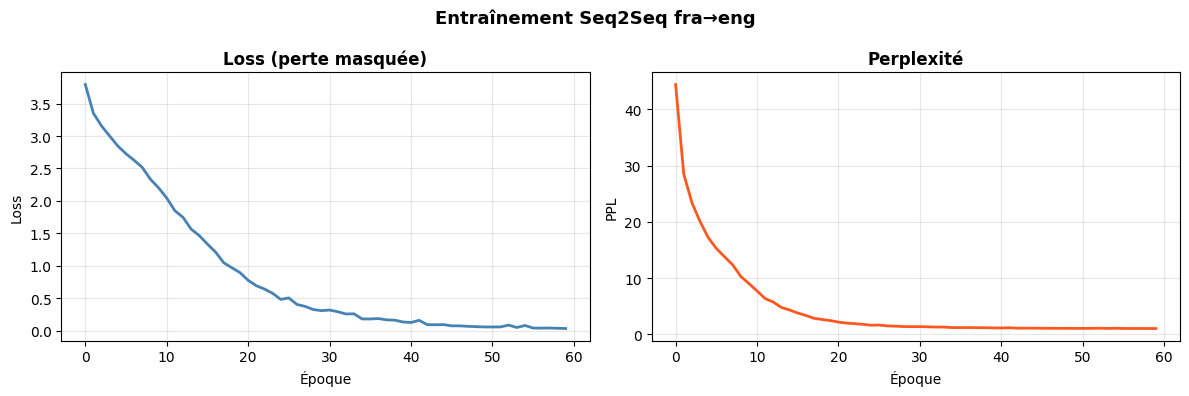

In [17]:
# ── CELLULE 17 – Courbes d'entraînement Seq2Seq ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_seq2seq['loss'], color='steelblue', linewidth=2)
axes[0].set_title('Loss (perte masquée)', fontweight='bold')
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_seq2seq['ppl'], color='#FF5722', linewidth=2)
axes[1].set_title('Perplexité', fontweight='bold')
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('PPL')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Entraînement Seq2Seq fra→eng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('seq2seq_training.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Décodage : glouton vs Beam search

### Décodage glouton
$$y_t = \arg\max_y P(y \mid y_{<t}, x)$$
Rapide mais sous-optimal globalement.

### Beam search (largeur k)
Conserve les $k$ meilleures hypothèses partielles à chaque étape :
$$\text{score}(y_{1:T}) = \frac{1}{T^\alpha} \sum_{t=1}^T \log P(y_t \mid y_{<t}, x)$$
Plus lent mais produit de meilleures traductions.

In [18]:
# ── CELLULE 18 – Décodage glouton ────────────────────────────────────────────
def greedy_decode(model, src_sentence, src_vocab, tgt_vocab, tgt_inv,
                  max_len=12):
    model.eval().cpu()
    src_ids = encode(src_sentence, src_vocab, max_len)
    src_in  = torch.tensor([src_ids])

    with torch.no_grad():
        enc_out, hidden = model.encoder(src_in)
        context   = enc_out[:, -1, :]
        dec_input = torch.tensor([tgt_vocab[BOS]])
        result    = []

        for _ in range(max_len):
            pred, hidden = model.decoder(dec_input, hidden, context)
            token        = pred.argmax(1).item()
            word         = tgt_inv[token]
            if word == EOS:
                break
            if word not in SPECIAL:
                result.append(word)
            dec_input = torch.tensor([token])

    return ' '.join(result)

print('=== Décodage glouton ===')
for fr, en in pairs[:8]:
    pred = greedy_decode(seq2seq, fr, src_vocab, tgt_vocab, tgt_inv)
    status = '✅' if pred.strip() == en.strip() else '⚠️ '
    print(f'  {status} FR: {fr:<32} Pred: {pred:<30} Ref: {en}')

=== Décodage glouton ===
  ✅ FR: je suis etudiant                 Pred: i am a student                 Ref: i am a student
  ✅ FR: il fait beau                     Pred: the weather is nice            Ref: the weather is nice
  ✅ FR: bonjour monde                    Pred: hello world                    Ref: hello world
  ✅ FR: je mange une pomme               Pred: i eat an apple                 Ref: i eat an apple
  ✅ FR: elle est belle                   Pred: she is beautiful               Ref: she is beautiful
  ✅ FR: nous aimons python               Pred: we love python                 Ref: we love python
  ✅ FR: le chat dort                     Pred: the cat sleeps                 Ref: the cat sleeps
  ✅ FR: je suis fatigue                  Pred: i am tired                     Ref: i am tired


In [19]:
# ── CELLULE 19 – Beam search ─────────────────────────────────────────────────
def beam_search(model, src_sentence, src_vocab, tgt_vocab, tgt_inv,
                beam_width=3, max_len=12, alpha=0.6):
    model.eval().cpu()
    src_ids = encode(src_sentence, src_vocab, max_len)
    src_in  = torch.tensor([src_ids])

    with torch.no_grad():
        enc_out, hidden = model.encoder(src_in)
        context   = enc_out[:, -1, :]

        # Faisceau initial : (score, tokens, hidden)
        beams     = [(0.0, [tgt_vocab[BOS]], hidden)]
        completed = []

        for _ in range(max_len):
            new_beams = []
            for score, tokens, h in beams:
                dec_in     = torch.tensor([tokens[-1]])
                pred, new_h = model.decoder(dec_in, h, context)
                log_probs  = F.log_softmax(pred, dim=1).squeeze(0)
                top_k      = log_probs.topk(beam_width)

                for lp, idx in zip(top_k.values, top_k.indices):
                    new_token  = idx.item()
                    new_score  = score + lp.item()
                    new_tokens = tokens + [new_token]

                    if tgt_inv[new_token] == EOS:
                        # Pénalisation de longueur
                        norm_score = new_score / (len(new_tokens) ** alpha)
                        completed.append((norm_score, new_tokens))
                    else:
                        new_beams.append((new_score, new_tokens, new_h))

            beams = sorted(new_beams,
                           key=lambda x: x[0] / (len(x[1]) ** alpha),
                           reverse=True)[:beam_width]
            if not beams:
                break

        if completed:
            best_tokens = max(completed, key=lambda x: x[0])[1][1:]
        elif beams:
            best_tokens = beams[0][1][1:]
        else:
            best_tokens = []

        words = [tgt_inv[t] for t in best_tokens if tgt_inv[t] not in SPECIAL]
    return ' '.join(words)

print('=== Beam search (k=3) ===')
for fr, en in pairs[:8]:
    pred = beam_search(seq2seq, fr, src_vocab, tgt_vocab, tgt_inv, beam_width=3)
    status = '✅' if pred.strip() == en.strip() else '⚠️ '
    print(f'  {status} FR: {fr:<32} Pred: {pred:<30} Ref: {en}')

=== Beam search (k=3) ===
  ✅ FR: je suis etudiant                 Pred: i am a student                 Ref: i am a student
  ✅ FR: il fait beau                     Pred: the weather is nice            Ref: the weather is nice
  ✅ FR: bonjour monde                    Pred: hello world                    Ref: hello world
  ✅ FR: je mange une pomme               Pred: i eat an apple                 Ref: i eat an apple
  ✅ FR: elle est belle                   Pred: she is beautiful               Ref: she is beautiful
  ✅ FR: nous aimons python               Pred: we love python                 Ref: we love python
  ✅ FR: le chat dort                     Pred: the cat sleeps                 Ref: the cat sleeps
  ✅ FR: je suis fatigue                  Pred: i am tired                     Ref: i am tired


---
## 11. Évaluation BLEU

In [20]:
# ── CELLULE 20 – Score BLEU ──────────────────────────────────────────────────
def bleu_score(pred, ref, max_n=2):
    """
    BLEU simplifié : précision des n-grammes pondérée par une pénalité de brièveté.
    max_n : ordre maximal des n-grammes (1 et 2 ici).
    """
    pred_tokens = pred.split()
    ref_tokens  = ref.split()
    if not pred_tokens:
        return 0.0

    # Pénalité de brièveté
    bp = min(1.0, len(pred_tokens) / max(len(ref_tokens), 1))

    score = 0.0
    for n in range(1, max_n + 1):
        pred_ng = collections.Counter(
            tuple(pred_tokens[i:i+n]) for i in range(len(pred_tokens)-n+1))
        ref_ng  = collections.Counter(
            tuple(ref_tokens[i:i+n])  for i in range(len(ref_tokens)-n+1))
        matches = sum((pred_ng & ref_ng).values())
        total   = max(sum(pred_ng.values()), 1)
        score  += matches / total

    return bp * score / max_n

# Comparaison glouton vs beam search
print(f"{'FR':<32} {'BLEU glouton':>13} {'BLEU beam':>10}")
print('-' * 58)
bleu_g_total, bleu_b_total = 0, 0
for fr, en in pairs:
    pred_g = greedy_decode(seq2seq, fr, src_vocab, tgt_vocab, tgt_inv)
    pred_b = beam_search(seq2seq,   fr, src_vocab, tgt_vocab, tgt_inv, beam_width=3)
    bg = bleu_score(pred_g, en)
    bb = bleu_score(pred_b, en)
    bleu_g_total += bg
    bleu_b_total += bb
    print(f"{fr:<32} {bg:>13.3f} {bb:>10.3f}")

n = len(pairs)
print('-' * 58)
print(f"{'BLEU moyen':<32} {bleu_g_total/n:>13.3f} {bleu_b_total/n:>10.3f}")

FR                                BLEU glouton  BLEU beam
----------------------------------------------------------
je suis etudiant                         1.000      1.000
il fait beau                             1.000      1.000
bonjour monde                            1.000      1.000
je mange une pomme                       1.000      1.000
elle est belle                           1.000      1.000
nous aimons python                       1.000      1.000
le chat dort                             1.000      1.000
je suis fatigue                          1.000      1.000
bonne nuit                               1.000      1.000
merci beaucoup                           1.000      1.000
je parle francais                        1.000      1.000
il aime le sport                         1.000      1.000
nous sommes heureux                      1.000      1.000
elle mange du pain                       1.000      1.000
bonjour comment vas tu                   1.000      1.000
je lis un liv

In [21]:
# ── CELLULE 21 – Sauvegarde ─────────────────────────────────────────────────
torch.save(seq2seq.state_dict(), 'seq2seq.pt')
print('Modèle Seq2Seq sauvegardé : seq2seq.pt')

# Rechargement
enc2 = Encoder(len(src_vocab))
dec2 = Decoder(len(tgt_vocab))
seq2seq_clone = Seq2Seq(enc2, dec2, len(tgt_vocab))
seq2seq_clone.load_state_dict(torch.load('seq2seq.pt', map_location='cpu'))
seq2seq_clone.eval()
print('Rechargement Seq2Seq : OK ✅')

# Vérification
pred_orig  = greedy_decode(seq2seq,       pairs[0][0], src_vocab, tgt_vocab, tgt_inv)
pred_clone = greedy_decode(seq2seq_clone, pairs[0][0], src_vocab, tgt_vocab, tgt_inv)
print(f'Original : {pred_orig}')
print(f'Clone    : {pred_clone}')

Modèle Seq2Seq sauvegardé : seq2seq.pt
Rechargement Seq2Seq : OK ✅
Original : i am a student
Clone    : i am a student


---
## 12. Question de synthèse

> **Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur–décodeur ?**

### Réponse

**Du RNN simple au LSTM/GRU.**  
Le RNN introduit la notion fondamentale de **mémoire récurrente** : l'état caché $h_t$ résume le contexte accumulé jusqu'au temps $t$. Cependant, lors de la rétropropagation à travers le temps (BPTT), le gradient doit traverser toute la chaîne temporelle via une multiplication répétée de matrices jacobiennes. Si les valeurs propres de ces matrices sont inférieures à 1, le gradient **s'évanuit** exponentiellement — le réseau oublie les dépendances lointaines. Si elles sont supérieures à 1, il **explose** — d'où l'utilité du gradient clipping.

Le LSTM résout ce problème en introduisant une **cellule mémoire** $c_t$ dont la mise à jour est contrôlée par des portes différentiables : la porte d'oubli ($f_t$) choisit ce qu'on efface, la porte d'entrée ($i_t$) choisit ce qu'on écrit, et la porte de sortie ($o_t$) choisit ce qu'on expose. Cette structure crée un **chemin direct** pour le gradient à travers $c_t$, atténuant fortement l'évanouissement. Le GRU simplifie cette mécanique à deux portes seulement (mise à jour et réinitialisation), sans cellule séparée, obtenant des performances similaires à moindre coût computationnel.

Nos expériences confirment : les trois architectures convergent vers des perplexités proches sur notre petit corpus, mais on s'attend à ce que LSTM et GRU dominent sur des séquences plus longues et plus complexes.

**Du modèle de langage au Seq2Seq.**  
Un RNN/LSTM/GRU utilisé comme modèle de langage prédit le prochain token de la **même** séquence. Pour la traduction, la source et la cible sont deux séquences de longueurs différentes et de langues différentes — un seul RNN ne peut pas naturellement gérer ce décalage. L'architecture **encodeur–décodeur** sépare clairement les deux rôles : l'encodeur compresse la source en un vecteur de contexte $c$, et le décodeur génère la cible conditionnellement à $c$.

Le **teacher forcing** accélère l'entraînement en fournissant le vrai token précédent au décodeur, mais crée un écart avec l'inférence (où le décodeur doit vivre avec ses propres erreurs). Le **beam search** atténue cet écart à l'inférence en explorant $k$ hypothèses en parallèle, produisant généralement de meilleures traductions que le décodage glouton.

**Limites observées.**  
Le Seq2Seq récurrent classique compresse toute la source en un **unique vecteur** $c$, ce qui crée un goulot d'étranglement sur les longues phrases. Cette limite a motivé l'invention du **mécanisme d'attention** (Bahdanau, 2015), qui permet au décodeur d'accéder à tous les états de l'encodeur à chaque pas, puis des **Transformers** (Vaswani, 2017) qui éliminent complètement la récurrence au profit de l'attention multi-têtes.

**Conclusion.**  
La progression RNN → LSTM/GRU → Seq2Seq → Attention → Transformer suit une logique claire : chaque étape répond à une limitation précise de l'étape précédente. Les architectures récurrentes restent une base pédagogique indispensable pour comprendre la modélisation séquentielle, même si en pratique les Transformers les ont largement supplantées.